In [ ]:
import sys
import os
import torch
from pathlib import Path

def get_project_info() -> Path:
  current = Path.cwd().resolve()
  root = current
  for parent in [current, *current.parents]:
    if (parent / "toy_transformers").exists():
      root = parent
      break
  return root, current

if 'ROOT_DIR' not in globals():
  ROOT_DIR, EXPERIMENT_DIR = get_project_info()
  if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))
  if Path.cwd() != ROOT_DIR:
    os.chdir(ROOT_DIR)

from toy_transformers.models import gptv4
from toy_transformers import tokenization, checkpoint
from data_loader import ShardedTokenDataset, create_splits

In [2]:
DEVICE = "mps"
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2

MAX_LR = 3e-4
MIN_LR = 3e-5
WARMUP_STEPS = 100
MAX_STEPS = 2000

EVAL_INTERVAL = 200
EVAL_BATCHES = 20
LOG_INTERVAL = 10

# small model just to verify E2E
config = gptv4.GPTv4Config(
  vocab_size=32768,
  block_size=256,
  device=DEVICE,
  n_heads=4,
  n_kv_heads=2,
  n_embed=128,
  n_layers=4,
)

In [3]:
FINEWEB_DIR = ROOT_DIR / "experiments/fineweb-edu-load/data"
VOCAB_PATH = FINEWEB_DIR / "vocab_32k.json"
SHARD_DIR = FINEWEB_DIR / "shuffled"

vocab = tokenization.Vocabulary.load(VOCAB_PATH)
# vocab is in BYTES mode — special token keys are bytes
BOS_ID = vocab.token_to_idx[b"<BOS>"]
PAD_ID = vocab.token_to_idx[b"<PAD>"]
print(f"vocab size: {len(vocab.tokens)}, BOS={BOS_ID}, PAD={PAD_ID}")

train_shards, val_shards, _ = create_splits(SHARD_DIR, val_shards=1, test_shards=0)
print(f"train shards: {len(train_shards)}, val shards: {len(val_shards)}")

vocab size: 32768, BOS=0, PAD=1
train shards: 77, val shards: 1


In [4]:
from torch.utils.data import DataLoader

train_ds = ShardedTokenDataset(
  shard_paths=train_shards,
  block_size=config.block_size,
  bos_id=BOS_ID,
  pad_id=PAD_ID,
  shuffle_docs=True,
  seed=42,
)
val_ds = ShardedTokenDataset(
  shard_paths=val_shards,
  block_size=config.block_size,
  bos_id=BOS_ID,
  pad_id=PAD_ID,
  shuffle_docs=False,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, drop_last=True)

print(f"effective batch: {BATCH_SIZE * GRAD_ACCUM_STEPS * config.block_size:,} tokens/step")

effective batch: 4,096 tokens/step


In [5]:
import time
torch.set_float32_matmul_precision("medium")

m = gptv4.LanguageModel(config).to(device=DEVICE)
print(f"{m.get_num_parameters(as_str=True)} parameters")

# set up optimizer before compile so we have access to get_optimizer
optimizer = m.get_optimizer(weight_decay=0.1, lr=MAX_LR)

# m.compile() compiles in-place (m stays a LanguageModel), unlike torch.compile(m)
# which wraps m in an OptimizedModule and breaks load_state_dict key names
try:
  m.compile()
  print("compiled")
except Exception as e:
  print(f"compile skipped: {e}")

scheduler = torch.optim.lr_scheduler.SequentialLR(
  optimizer,
  schedulers=[
    torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1/WARMUP_STEPS, total_iters=WARMUP_STEPS),
    torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_STEPS - WARMUP_STEPS, eta_min=MIN_LR),
  ],
  milestones=[WARMUP_STEPS],
)

CKPT_DIR: Path = EXPERIMENT_DIR / "checkpoints"
TEMP_CKPT = CKPT_DIR / "temp"
TRAINING_CONFIG = {
  "max_lr": MAX_LR,
  "min_lr": MIN_LR,
  "warmup_steps": WARMUP_STEPS,
  "max_steps": MAX_STEPS,
  "batch_size": BATCH_SIZE,
  "grad_accum_steps": GRAD_ACCUM_STEPS,
  "effective_batch_tokens": BATCH_SIZE * GRAD_ACCUM_STEPS * config.block_size,
  "vocab_path": str(VOCAB_PATH),
}

4.916m parameters
compiled


In [6]:
@torch.no_grad()
def estimate_loss(model, loader, n_batches=EVAL_BATCHES):
  model.eval()
  losses = []
  for i, (x, y, doc_ids, loss_mask) in enumerate(loader):
    if i >= n_batches: break
    x, y = x.to(DEVICE), y.to(DEVICE)
    doc_ids = doc_ids.to(DEVICE)
    loss_mask = loss_mask.to(DEVICE)
    with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16):
      _, loss = model(x, y, doc_ids=doc_ids, loss_mask=loss_mask)
    losses.append(loss.item())
  model.train()
  return sum(losses) / len(losses)

In [8]:
metrics = []
step = 0
best_val_loss = float("inf")

if TEMP_CKPT.exists():
  print("resuming from temp checkpoint...")
  loaded_model, _, _, saved_metrics, opt_state, sched_state = checkpoint.load(
    TEMP_CKPT, gptv4.LanguageModel, gptv4.GPTv4Config, device=DEVICE
  )
  m.load_state_dict(loaded_model.state_dict())
  if opt_state: optimizer.load_state_dict(opt_state)
  if sched_state: scheduler.load_state_dict(sched_state)
  if saved_metrics:
    metrics = saved_metrics
    step = metrics[-1].get("step", 0)
    val_losses = [row["val_loss"] for row in metrics if "val_loss" in row and row["val_loss"]]
    if val_losses: best_val_loss = min(val_losses)
else:
  print("starting fresh")

m.train()
t0 = time.time()
micro_batch_buffer = []

try:
  for x, y, doc_ids, loss_mask in train_loader:
    if step >= MAX_STEPS:
      break

    x, y = x.to(DEVICE), y.to(DEVICE)
    doc_ids = doc_ids.to(DEVICE)
    loss_mask = loss_mask.to(DEVICE)
    micro_batch_buffer.append((x, y, doc_ids, loss_mask))

    if len(micro_batch_buffer) < GRAD_ACCUM_STEPS:
      continue

    optimizer.zero_grad(set_to_none=True)
    loss_accum = 0.0

    for mx, my, mdoc, mmask in micro_batch_buffer:
      with torch.autocast(device_type=DEVICE, dtype=torch.bfloat16):
        _, loss = m(mx, my, doc_ids=mdoc, loss_mask=mmask)
      loss = loss / GRAD_ACCUM_STEPS
      loss.backward()
      loss_accum += loss.item()

    torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
    step += 1
    micro_batch_buffer = []

    if step % LOG_INTERVAL == 0:
      dt = time.time() - t0
      tokens_per_sec = (LOG_INTERVAL * BATCH_SIZE * GRAD_ACCUM_STEPS * config.block_size) / dt
      lr = scheduler.get_last_lr()[0]
      row = {"step": step, "train_loss": loss_accum, "lr": lr}
      print(f"step {step:5d} | loss {loss_accum:.4f} | lr {lr:.2e} | tok/s {tokens_per_sec:.0f}")
      metrics.append(row)
      t0 = time.time()

    if step % EVAL_INTERVAL == 0:
      val_loss = estimate_loss(m, val_loader)
      print(f"\t>>> val_loss: {val_loss:.4f}, best: {best_val_loss:.4f}")
      if metrics:
        metrics[-1]["val_loss"] = val_loss
      if val_loss < best_val_loss:
        best_val_loss = val_loss
      t0 = time.time()

  print(f"done at step {step}")
  checkpoint.save(
    CKPT_DIR / f"step-{step}",
    m, config, TRAINING_CONFIG,
    metrics,
    optimizer=optimizer, scheduler=scheduler
  )

except KeyboardInterrupt:
  print(f"interrupted at step {step}, saving...")
  checkpoint.save(
    TEMP_CKPT,
    m, config, TRAINING_CONFIG,
    metrics,
    optimizer=optimizer, scheduler=scheduler
  )
  print("saved!")

resuming from temp checkpoint...
step    60 | loss 9.5663 | lr 1.87e-04 | tok/s 8921
step    70 | loss 9.3398 | lr 2.17e-04 | tok/s 9259
step    80 | loss 9.1756 | lr 2.47e-04 | tok/s 9314
step    90 | loss 8.8911 | lr 2.76e-04 | tok/s 9600


/Users/sriman/dev/apps/toy-transformers/venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


step   100 | loss 8.5435 | lr 3.00e-04 | tok/s 9378
step   110 | loss 8.4736 | lr 3.00e-04 | tok/s 9537
step   120 | loss 8.2824 | lr 3.00e-04 | tok/s 9160
step   130 | loss 8.0404 | lr 3.00e-04 | tok/s 8957
step   140 | loss 7.9705 | lr 3.00e-04 | tok/s 9964
step   150 | loss 7.8965 | lr 3.00e-04 | tok/s 9581
step   160 | loss 7.6790 | lr 2.99e-04 | tok/s 9461
step   170 | loss 7.7351 | lr 2.99e-04 | tok/s 9561
step   180 | loss 7.6787 | lr 2.99e-04 | tok/s 9681
step   190 | loss 7.6036 | lr 2.98e-04 | tok/s 9423
step   200 | loss 7.8082 | lr 2.98e-04 | tok/s 9251


/Users/sriman/dev/apps/toy-transformers/venv/lib/python3.11/site-packages/torch/_inductor/lowering.py:1890: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(
W0228 23:17:42.790000 50589 torch/_inductor/utils.py:1436] [0/1] Not enough SMs to use max_autotune_gemm mode


	>>> val_loss: 7.6092, best: inf
step   210 | loss 7.4676 | lr 2.98e-04 | tok/s 9238
step   220 | loss 7.4720 | lr 2.97e-04 | tok/s 9404
step   230 | loss 7.6457 | lr 2.97e-04 | tok/s 9509
step   240 | loss 7.5485 | lr 2.96e-04 | tok/s 9689
step   250 | loss 7.3754 | lr 2.96e-04 | tok/s 9692
step   260 | loss 7.3450 | lr 2.95e-04 | tok/s 9390
step   270 | loss 7.4178 | lr 2.95e-04 | tok/s 9588
step   280 | loss 7.2365 | lr 2.94e-04 | tok/s 9552
step   290 | loss 7.5251 | lr 2.93e-04 | tok/s 9560
step   300 | loss 7.2365 | lr 2.93e-04 | tok/s 9590
step   310 | loss 7.1743 | lr 2.92e-04 | tok/s 9772
step   320 | loss 7.3095 | lr 2.91e-04 | tok/s 9518
step   330 | loss 7.2445 | lr 2.90e-04 | tok/s 9643
step   340 | loss 7.1732 | lr 2.89e-04 | tok/s 9570
step   350 | loss 7.2020 | lr 2.88e-04 | tok/s 9429
step   360 | loss 7.0208 | lr 2.88e-04 | tok/s 9775
step   370 | loss 7.1856 | lr 2.87e-04 | tok/s 9717
step   380 | loss 7.0263 | lr 2.86e-04 | tok/s 9554
step   390 | loss 6.9294 | lr 2

In [9]:
prompt = "The history of"
# vocab is BYTES mode: encode expects bytes, decode returns list of bytes
encoded = vocab.encode(prompt.encode("utf-8"))
idx = torch.tensor([encoded], dtype=torch.long, device=DEVICE)
print(prompt, end="", flush=True)
for token in m.generate(idx, max_new_tokens=200, temperature=0.8, topk=40):
  tok_bytes = vocab.decode([token.item()])  # List[bytes]
  print(b"".join(tok_bytes).decode("utf-8", errors="replace"), end="", flush=True)
print()

The history of the end

/Users/sriman/dev/apps/toy-transformers/venv/lib/python3.11/site-packages/torch/_dynamo/utils.py:3421: UserWarning: record_context_cpp is not support on non-linux non-x86_64 platforms (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/profiler/unwind/unwind.cpp:12.)
  return node.target(*args, **kwargs)


 of the American War War of the 20 million, 15, 2017 and 2) a variety of those who was the day in the body of many years. Many of the 4th century century and the 2016 percent of these of the United States, the body's University 1993, 2014. 1.7, 2016, 5,15, 10 months, 10,000 3, 2010. In 30, 2010 is that is found in the most of 30 years. The 16% of the 1950s.
N-3-1, 1954, 2015 2.3, 19.5).
31). The second 15 years, 20th, the 2000s, 11, 2 in 2013 (1
How to 180 by the  1940. In 1 (


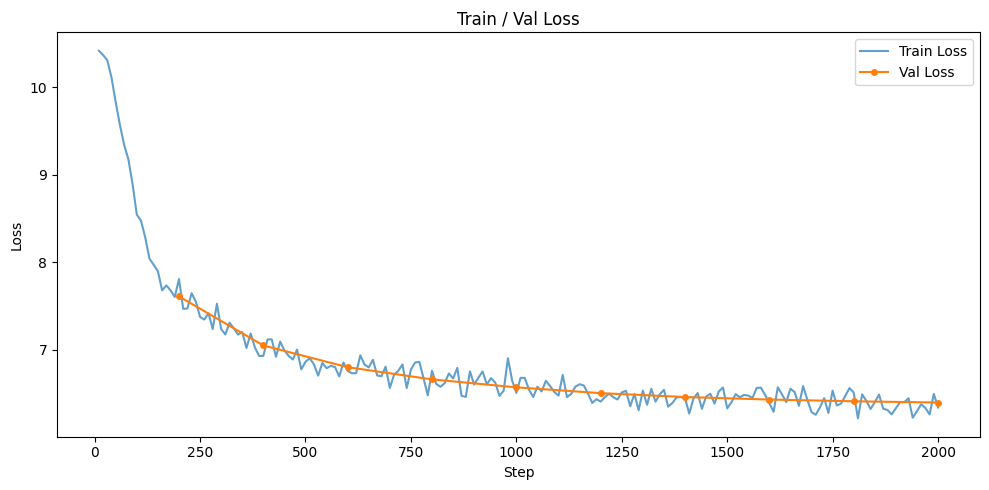

In [10]:
import matplotlib.pyplot as plt

steps = [row["step"] for row in metrics]
train_loss = [row["train_loss"] for row in metrics]
val_steps = [row["step"] for row in metrics if "val_loss" in row]
val_loss = [row["val_loss"] for row in metrics if "val_loss" in row]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, train_loss, label="Train Loss", alpha=0.7)
ax.plot(val_steps, val_loss, label="Val Loss", marker="o", markersize=4)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Train / Val Loss")
ax.legend()
plt.tight_layout()
plt.show()